# Pre-processing: WorldPop population data

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio

from d_health import align_flood_and_population, get_population_data

## 2. Configure the run

Pick the country (ISO3) and year, define the area of interest, and choose an output directory. Here we use a hand-set bounding box around **Paramaribo** (Suriname's capital) instead of an external flood map. WorldPop downloads will be clipped to those bounds — only the cells inside Paramaribo are kept; the rest are never written to disk.

In [2]:
country = "SUR"   # Suriname
year = 2020
output_dir = Path("./outputs")

# Paramaribo bounding box in EPSG:4326 (xmin, ymin, xmax, ymax)
paramaribo_bounds = (-55.27, 5.78, -55.10, 5.93)

## 3. Fetch and aggregate (clipped to Paramaribo)

Pass the bounding box as the `clip` argument. `get_population_data` downloads each per-age raster into a temp directory, masks it to the clip bounds, sums in memory, and writes only the final 3-band raster to `output_dir`. The raw per-age files are deleted as they're consumed — nothing persists outside `output_dir`.

Bands written: `children_0_9`, `adults_10_plus`, `total`.

In [3]:
raster_path = get_population_data(
    country, year, output_dir / "population",
    clip=paramaribo_bounds,
)
raster_path

WindowsPath('outputs/population/sur_population_2020_combined.tif')

## 4. Inspect the output

Sanity-check: 3 bands, the right names, and `total ≈ children + adults`.

In [4]:
with rasterio.open(raster_path) as src:
    assert src.count == 3, src.count
    print("CRS:         ", src.crs)
    print("Shape:       ", src.shape)
    print("Bands:       ", src.descriptions)
    children = src.read(1)
    adults = src.read(2)
    total = src.read(3)

print(f"\nChildren (0-9):  {children.sum():>14,.0f}")
print(f"Adults (10+):    {adults.sum():>14,.0f}")
print(f"Total:           {total.sum():>14,.0f}")

np.testing.assert_allclose(total, children + adults, rtol=1e-5)
print("\nIdentity check passed: total == children + adults")

CRS:          EPSG:4326
Shape:        (181, 205)
Bands:        ('children_0_9', 'adults_10_plus', 'total')

Children (0-9):          49,294
Adults (10+):           264,452
Total:                  313,746

Identity check passed: total == children + adults


## 5. Visualise

Quick log-scaled view of each band, side-by-side.

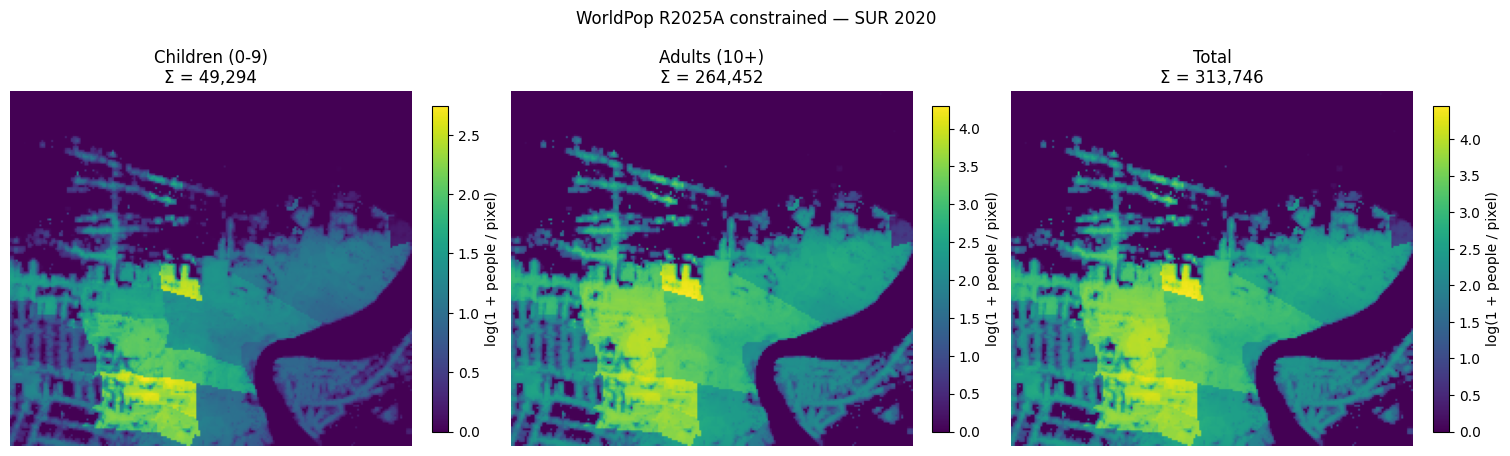

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
for ax, band, title in zip(axes, (children, adults, total),
                            ("Children (0-9)", "Adults (10+)", "Total")):
    img = ax.imshow(np.log1p(band), cmap="viridis")
    ax.set_title(f"{title}\nΣ = {band.sum():,.0f}")
    ax.set_axis_off()
    fig.colorbar(img, ax=ax, shrink=0.7, label="log(1 + people / pixel)")
fig.suptitle(f"WorldPop R2025A constrained — {country} {year}")
plt.show()

## 6. Build a synthetic flood-depth map

Real flood maps come from hydrodynamic models. For demonstration purposes we generate a small synthetic flood depth raster inside the Paramaribo bounds at finer-than-100 m resolution: two overlapping Gaussian peaks giving depths up to ~2.5 m. This stands in for what a real flood-depth GeoTIFF would look like and lets us exercise the alignment step end-to-end without external data.

Dummy flood: outputs\flood\dummy_flood_depth.tif
  shape: (233, 299), max depth: 2.51 m, ~33 m / pixel


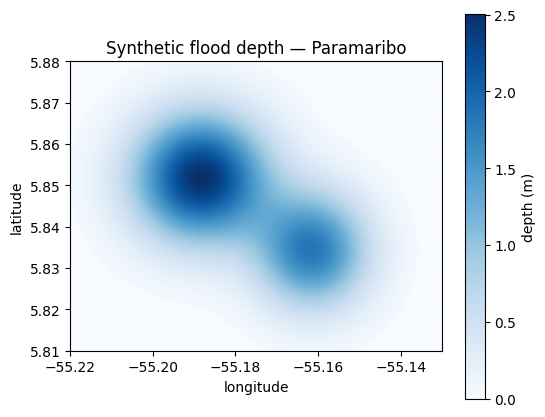

In [6]:
from rasterio.transform import from_bounds as transform_from_bounds

# Synthetic flood inside Paramaribo at ~33 m resolution (0.0003° ≈ 33 m at 5.85°N)
flood_bounds = (-55.22, 5.81, -55.13, 5.88)
res = 0.0003

xmin, ymin, xmax, ymax = flood_bounds
width = int((xmax - xmin) / res)
height = int((ymax - ymin) / res)

yy, xx = np.mgrid[0:height, 0:width]
depth = np.zeros((height, width), dtype=np.float32)
for cx_frac, cy_frac, peak, sx_frac, sy_frac in [
    (0.35, 0.40, 2.5, 0.18, 0.22),
    (0.65, 0.65, 1.8, 0.15, 0.20),
]:
    cx, cy = cx_frac * width, cy_frac * height
    sx, sy = sx_frac * width, sy_frac * height
    depth += peak * np.exp(-(((xx - cx) / sx) ** 2 + ((yy - cy) / sy) ** 2))
depth[depth < 0.05] = 0  # noise floor

flood_path = output_dir / "flood" / "dummy_flood_depth.tif"
flood_path.parent.mkdir(parents=True, exist_ok=True)
transform = transform_from_bounds(xmin, ymin, xmax, ymax, width, height)
profile = dict(
    driver="GTiff", height=height, width=width, count=1, dtype="float32",
    crs="EPSG:4326", transform=transform, nodata=0, compress="deflate",
)
with rasterio.open(flood_path, "w", **profile) as dst:
    dst.write(depth, 1)
    dst.descriptions = ("flood_depth_m",)

print(f"Dummy flood: {flood_path}")
print(f"  shape: {depth.shape}, max depth: {depth.max():.2f} m, ~{res * 111_000:.0f} m / pixel")

plt.figure(figsize=(6, 5))
plt.imshow(depth, cmap="Blues", extent=(xmin, xmax, ymin, ymax))
plt.colorbar(label="depth (m)")
plt.title("Synthetic flood depth — Paramaribo")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

## 7. Align flood depth onto the population grid

Flood depth maps are typically finer than 100 m. We resample the flood raster onto the WorldPop grid using **`average`**, so each 100 m cell carries `flooded_fraction × mean_depth_when_flooded`. The **flood map's extent defines the final output footprint**: the population is window-clipped to match. Both rasters end up on an identical grid ready for cell-wise impact math.

In [7]:
aligned_dir = output_dir / "aligned"

flood_aligned, pop_clipped = align_flood_and_population(
    flood_path=flood_path,
    population_path=raster_path,
    output_dir=aligned_dir,
    resampling="average",
)
print("Aligned flood:", flood_aligned)
print("Clipped pop:  ", pop_clipped)

Aligned flood: outputs\aligned\dummy_flood_depth_on_pop_grid.tif
Clipped pop:   outputs\aligned\sur_population_2020_combined_clipped.tif


Common grid: (84, 108) @ (0.00083333333, 0.00083333333) in EPSG:4326


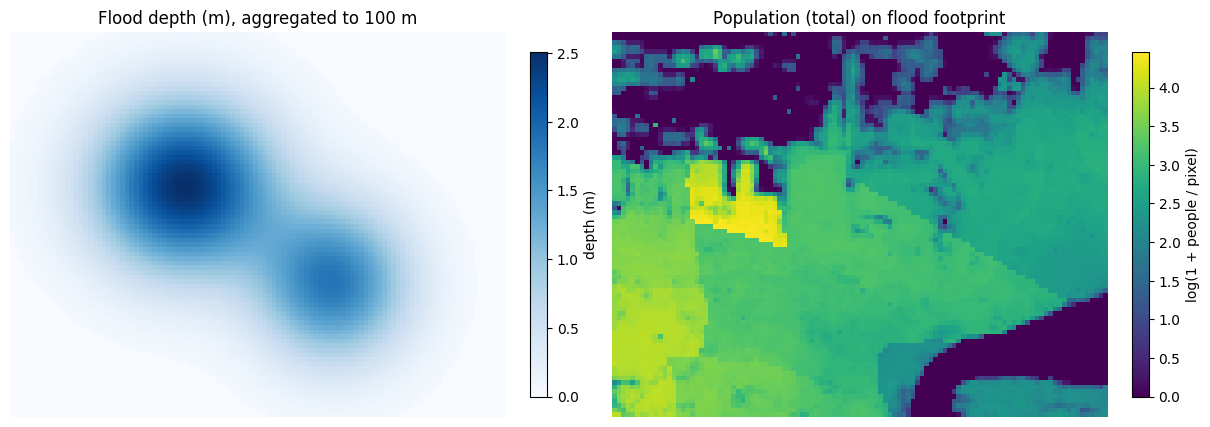

In [8]:
with rasterio.open(flood_aligned) as f, rasterio.open(pop_clipped) as p:
    assert f.shape == p.shape
    assert f.transform == p.transform
    assert f.crs == p.crs
    depth = f.read(1)
    pop_total = p.read(p.count)  # last band is total in our 3-band layout
    print(f"Common grid: {f.shape} @ {f.res} in {f.crs}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
im0 = axes[0].imshow(depth, cmap="Blues")
axes[0].set_title("Flood depth (m), aggregated to 100 m")
axes[0].set_axis_off()
fig.colorbar(im0, ax=axes[0], shrink=0.7, label="depth (m)")

im1 = axes[1].imshow(np.log1p(pop_total), cmap="viridis")
axes[1].set_title("Population (total) on flood footprint")
axes[1].set_axis_off()
fig.colorbar(im1, ax=axes[1], shrink=0.7, label="log(1 + people / pixel)")
plt.show()